In [14]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Mini-projet 2 – Effacement de consommation



## Partie 1 : Étude du problème d'optimisation

**Question 1: Justifiaction de la facture**

La puissance $P_i$ est supposée constante sur l'intervalle $[t_i, t_{i+1}]$ de durée $\Delta t$. L'énergie consommée sur cet intervalle est donc $P_i \Delta t$ (en Wh). Le coût associé, au tarif $c_i$, est $c_i P_i \Delta t$. En sommant sur tous les intervalles $i = 0, \ldots, N$, avec la convention $P_N = 0$ (condition terminale (3)), on obtient :
$$\text{Facture} = \Delta t \sum_{i=0}^{N} c_i P_i = \Delta t \sum_{i=0}^{N-1} c_i P_i$$
ce qui est bien la formule (5).

**Question 2: Interprétation de l'équation**

L'équation
$$T_{i+1} = e^{-(k+h)\Delta t} T_i + \frac{1 - e^{-(k+h)\Delta t}}{k+h}\left(bP_i + hT^e_i\right)$$
Cette équation différentielle nous parait raisonnable car en faisant tendre $\Delta t$  vers $0$ on obtient l'équation différentielle suivante:
$$\dot{T}(t) = -(k+h)T(t) + bP(t) + hT^e(t)$$
sur l'intervalle $[t_i, t_{i+1}]$, avec $P$ et $T^e$ constants sur cet intervalle.

Cette EDO modélise deux échanges thermiques :
- Pertes thermiques vers l'extérieur: le terme $-kT$ modélise les déperditions de chaleur à travers les murs et le toit, proportionnelles à la température intérieure (par rapport à une référence nulle), le terme $h(T^e - T)$ modélise l'échange thermique avec l'air extérieur, proportionnel à l'écart de température $T^e - T$. 
- Apport de chaleur par le chauffage : le terme $bP$ représente la puissance thermique injectée par les convecteurs.



**Question 3: Formulation du problème d'optimisation** 

On choisit comme variables de décision les puissances de chauffage et les températures à chaque pas de temps :
$$x = (P_0, \ldots, P_{N-1}, T_0, \ldots, T_N) \in \mathbb{R}^{2N+1}$$
soit $n = 2N + 1$ variables. 

On notera que même si les $T_i$ peuvent s'exrpimer en fonction de $P_i$ et inversement, il est plus faciles d'inclure la température dans les variables de décision afin de reduire la complexité des calculs des $T_i$ après optimisation sur la puissance.

**Fonction coût**
$$f(x) = \Delta t \sum_{i=0}^{N-1} c_i P_i$$
C'est une fonction **linéaire** en $x$.

**Contraintes d'égalité** $c_{eq}(x) = 0$ :
- Condition initiale : $T_0 - T_{in} = 0$
- Dynamique (2) pour $i = 0, \ldots, N-1$ :
$$T_{i+1} - e^{-(k+h)\Delta t} T_i - \frac{1-e^{-(k+h)\Delta t}}{k+h} b P_i = \frac{1-e^{-(k+h)\Delta t}}{k+h} h T^e_i$$

Ce sont $N+1$ équations **affines** en $(P_i, T_i)$.

**Contraintes d'inégalité** $c_{in}(x) \leq 0$ :
- Bornes sur la puissance : $-P_i \leq 0$ et $P_i - P_M \leq 0$ pour $i = 0, \ldots, N-1$
- Confort thermique : $T_m - T_i \leq 0$ et $T_i - T_M \leq 0$ pour $i \in I_{occ}$

Ce sont toutes des contraintes **affines** en $x$.

**Question 4: Convexité et famille du problème**

Le problème est une minimisation d'une fonction linéaire sous contraintes affines. C'est donc un problème de programmation linéaire (LP). Il appartient à la famille des problèmes à contraintes affines étudiée à la section 2.2.2.1 du cours (cas des contraintes affines, problème (34)).

La fonction coût est convexe (linéaire) et les contraintes d'inégalité aussi donc tout minimum local est un minimum global.

## Partie 2 : Résolution numérique du problème individuel

**Question 5: Méthodes de résolution.** Le problème étant un LP, on peut utiliser :
- la méthode du simplexe (algorithme de contraintes actives adapté aux LP, Appendice C.3 du cours)
- les méthodes de points intérieurs (barrière logarithmique)

Nous utilisons ici le solveur HiGHS via CasADi, qui implémente ces deux approches


**Question 6**

In [15]:
# on établit les paramètres 
t0 = 23.0
dt = 0.5
N = 48

c_cr = 1.0
c_pl = 3/2

T_m = 18.0
T_M = 30.0
T_in = T_m

h = 0.05
k = 0.01
b = 1/500
P_M = 5000.0

t = np.array([(t0 + i * dt) % 24 for i in range(N + 1)])
T_ext = 4 + 8 * np.exp(-(t - 12)**2 / 40)

def heure_creuse(heure):
    return (0 <= heure < 6) or (12 <= heure < 14)

def occupe(heure):
    return (7 <= heure <= 9) or (18 <= heure <= 23)

c_tarif = np.array([c_cr if heure_creuse(t[i]) else c_pl for i in range(N + 1)])
I_occ = [i for i in range(N + 1) if occupe(t[i])]

In [16]:
def solve_effacement(c_pl_val):
    c_tarif_loc = np.array([c_cr if heure_creuse(t[i]) else c_pl_val for i in range(N + 1)])
#création de "variables symboliques" pou casADi
    P = ca.SX.sym('P', N)
    T = ca.SX.sym('T', N + 1)
#on groupe les deux ( taille 2n+1)
    x = ca.vertcat(P, T)
#fonction coût
    f = dt * ca.dot(c_tarif_loc[:N], P)
#on simplifie l'expression des constantes
    alpha = np.exp(-(k + h) * dt)
    beta = (1 - alpha) / (k + h)

    g = []
    lbg = []
    ubg = []

# condition initiales
    g.append(T[0])
    lbg.append(T_in)
    ubg.append(T_in)

# on calcule la temperaure du batipment à chaque intervalle de temps
    for i in range(N):
        g.append(T[i + 1] - alpha * T[i] - beta * b * P[i])
        lbg.append(beta * h * T_ext[i])
        ubg.append(beta * h * T_ext[i])

# on pose les contraintes de température aux heures d'occupation
    for i in I_occ:
        g.append(T[i])
        lbg.append(T_m)
        ubg.append(T_M)

    g = ca.vertcat(*g)

    lp = {'x': x, 'f': f, 'g': g}
    solver = ca.qpsol('solver', 'highs', lp) #on réecrit le problème avec le nouveau vecteur contrainte g

    lbx = [0.0] * N + [-ca.inf] * (N + 1)
    ubx = [P_M] * N + [ca.inf] * (N + 1)

    sol = solver(lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)

    P_sol = np.array(sol['x'][:N]).flatten()
    T_sol = np.array(sol['x'][N:]).flatten()
    facture = float(sol['f'])

    return P_sol, T_sol, facture

In [17]:
P_opt, T_opt, facture = solve_effacement(c_pl)
print(f"Facture optimale : {facture:.2f}")
print(f"Température min : {T_opt.min():.2f} °C, max : {T_opt.max():.2f} °C")

Facture optimale : 8921.53
Température min : 13.78 °C, max : 22.77 °C


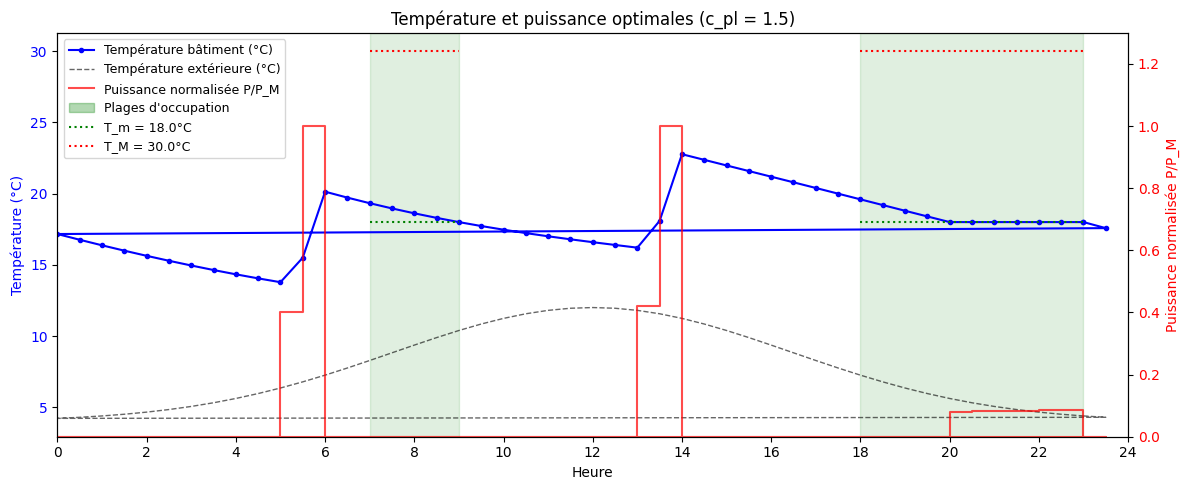

In [18]:
# Graphique (a), température et puissance normalisée ( on divise P par P_M)
fig, ax1 = plt.subplots(figsize=(12, 5))

for ts, te in [(7, 9), (18, 23)]:
    ax1.axvspan(ts, te, alpha=0.12, color='green')

ax1.plot(t, T_opt, 'b-o', markersize=3, label='Température bâtiment (°C)')
ax1.plot(t, T_ext, 'k--', linewidth=1, alpha=0.6, label='Température extérieure (°C)')

for ts, te in [(7, 9), (18, 23)]:
    ax1.hlines(T_m, ts, te, colors='green', linestyles=':', linewidth=1.5)
    ax1.hlines(T_M, ts, te, colors='red', linestyles=':', linewidth=1.5)

ax1.set_xlabel('Heure')
ax1.set_ylabel('Température (°C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(range(0, 25, 2))
ax1.set_xlim(0, 24)

ax2 = ax1.twinx() #on copie l'axe x précédent
P_plot = np.append(P_opt, 0.0)
ax2.step(t, P_plot / P_M, 'r-', where='post', linewidth=1.5, alpha=0.7, label='Puissance normalisée P/P_M')
ax2.set_ylabel('Puissance normalisée P/P_M', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, 1.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
occ_patch = mpatches.Patch(color='green', alpha=0.3, label="Plages d'occupation")
Tm_line = plt.Line2D([0], [0], color='green', linestyle=':', label=f'T_m = {T_m}°C')
TM_line = plt.Line2D([0], [0], color='red', linestyle=':', label=f'T_M = {T_M}°C')
ax1.legend(handles=lines1 + lines2 + [occ_patch, Tm_line, TM_line], loc='upper left', fontsize=9)

plt.title(f'Température et puissance optimales (c_pl = {c_pl})')
plt.tight_layout()# pour eviter que les légendes se recoupent 
# Graphique (b) : puissance normalisée vs tarif corrigéplt.show()

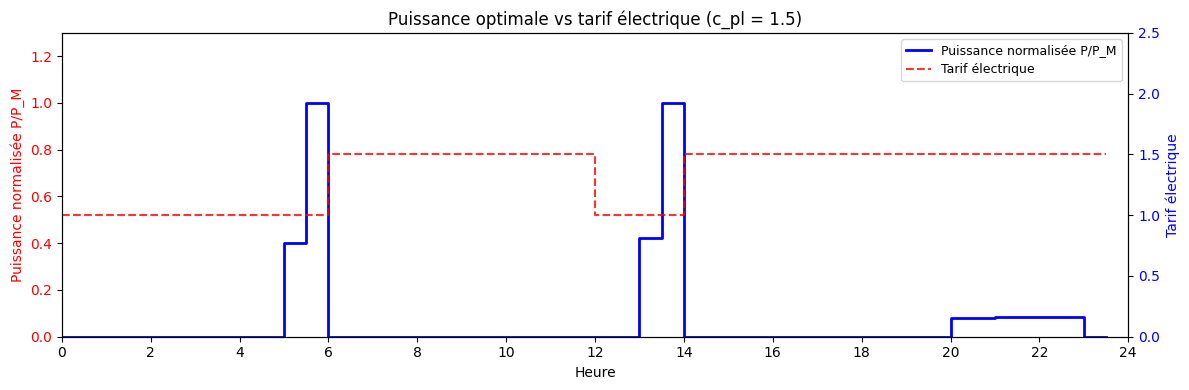

In [19]:
#Graphique B: puissance normalisée vs tarif

sort_idx = np.argsort(t)
t_sorted = t[sort_idx]
P_plot_sorted = P_plot[sort_idx]
c_tarif_sorted = c_tarif[sort_idx]


fig, ax1 = plt.subplots(figsize=(12, 4))

# puissance normalisée 
ax1.step(t_sorted, P_plot_sorted / P_M, 'b-', where='post', linewidth=2, label='Puissance normalisée P/P_M')
ax1.set_ylabel('Puissance normalisée P/P_M', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.set_ylim(0, 1.3)
ax1.set_xticks(range(0, 25, 2))
ax1.set_xlim(0, 24)
ax1.set_xlabel('Heure')

ax2 = ax1.twinx()
# tarif électrique 
ax2.step(t_sorted, c_tarif_sorted, 'r--', where='post', linewidth=1.5, alpha=0.8, label='Tarif électrique')
ax2.set_ylabel('Tarif électrique', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.set_ylim(0, 2.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles=lines1 + lines2, loc='upper right', fontsize=9)

plt.title(f'Puissance optimale vs tarif électrique (c_pl = {c_pl})')
plt.tight_layout()
plt.show()

**Question 7**

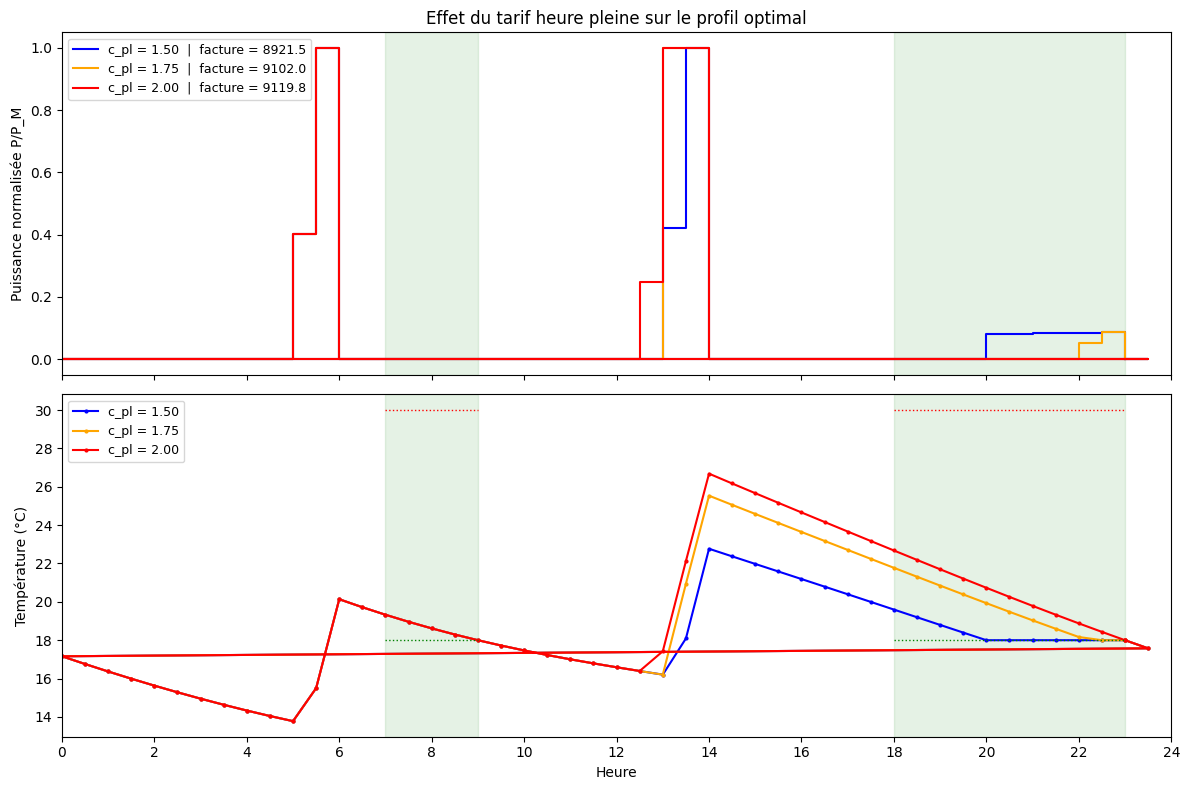

In [20]:
# On compare omparaison pour c_pl = 3/2, 7/4, 2
c_pl_values = [3/2, 7/4, 2]
colors = ['blue', 'orange', 'red']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for c_pl_v, col in zip(c_pl_values, colors):
    P_v, T_v, facture_v = solve_effacement(c_pl_v)
    P_plot_v = np.append(P_v, 0.0)
    axes[0].step(t, P_plot_v / P_M, where='post', color=col, linewidth=1.5,
                 label=f'c_pl = {c_pl_v:.2f}  |  facture = {facture_v:.1f}')
    axes[1].plot(t, T_v, color=col, linewidth=1.5, marker='o', markersize=2,
                 label=f'c_pl = {c_pl_v:.2f}')

for ax in axes:
    for ts, te in [(7, 9), (18, 23)]:
        ax.axvspan(ts, te, alpha=0.1, color='green')
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlim(0, 24)
    ax.legend(fontsize=9)

for ts, te in [(7, 9), (18, 23)]:
    axes[1].hlines(T_m, ts, te, colors='green', linestyles=':', linewidth=1)
    axes[1].hlines(T_M, ts, te, colors='red', linestyles=':', linewidth=1)

axes[0].set_ylabel('Puissance normalisée P/P_M')
axes[1].set_ylabel('Température (°C)')
axes[1].set_xlabel('Heure')
axes[0].set_title('Effet du tarif heure pleine sur le profil optimal')

plt.tight_layout()
plt.show()

**Commentaire.** Plus l'écart entre tarif heure pleine et heure creuse est important, plus le préchauffage nocturne est poussé : pour $c_{pl} = 2$, le chauffage tourne à pleine puissance ($P = P_M$) pendant toute la plage creuse de nuit. La facture diminue avec $c_{pl}$ croissant car l'optimiseur exploite davantage les heures les moins chères. Cela illustre l'**effet incitatif du tarif** : un signal-prix plus fort entraîne un déplacement plus marqué de la consommation vers les heures creuses.



## Partie 3 : Régulation collective

**Question 8: Nouveau problème d'optimisation**

On considère $n_l = 2$ logements. La dynamique du logement $j$ est désormais couplée à celle du voisin via l'équation (9). Ce couplage est affine en $(P^j_i, T^j_i, T^k_i)$ : les coefficients $h_{jk}$ sont des paramètres fixes. Le problème reste donc un LP, exactement dans le cadre de la section 2.2.2.1 du cours (contraintes affines, problème (34)), résolu par l'algorithme du simplexe (Appendice C.3).

Les variables de décision sont
$$x = (P^1_0,\ldots,P^1_{N-1},\; P^2_0,\ldots,P^2_{N-1},\; T^1_0,\ldots,T^1_N,\; T^2_0,\ldots,T^2_N) \in \mathbb{R}^{2(2N+1)}.$$

Le coût est la facture totale :
$$\min \; \Delta t \sum_{i=0}^{N-1} c_i \left(P^1_i + P^2_i\right)$$

Les contraintes d'égalité sont la dynamique (9) pour chaque logement et les conditions initiales $T^j_0 = T^j_m$ (chaque logement démarre à sa propre température minimale). Les contraintes d'inégalité sont les bornes $0 \leq P^j_i \leq P_M$ et les contraintes de confort $T^j_m \leq T^j_i \leq T_M$ pour $i \in I_{occ}$, avec $T^1_m = 18°C$ et $T^2_m = 20°C$.

**Question 9**
**Avantages.** L'optimiseur dispose de l'information complète sur les deux logements et peut exploiter le couplage thermique : quand un logement chauffe, il transfère de la chaleur à son voisin, ce que l'optimiseur utilise pour réduire la facture totale. Cela garantit l'optimum global sur l'ensemble du système 

**Inconvénients.** L'optimiseur doit connaître les paramètres thermiques et les préférences de confort de chaque logement. De plus, le problème grossit linéairement avec $n_l$ : pour un grand immeuble, le nombre de variables et de contraintes devient important. 

In [21]:
# Paramètres (modifiables à la volée)
t0   = 23.0
dt   = 0.5
N    = 48

c_cr = 1.0
c_pl = 3/2

T_M   = 30.0
T_m1  = 18.0
T_m2  = 20.0
#les deux logements n'ont pas les mêmes exigences#
T_in1 = T_m1
T_in2 = T_m2

h    = 0.05
k    = 0.01
b    = 1/500
P_M  = 5000.0
h12  = h

t = np.array([(t0 + i * dt) % 24 for i in range(N + 1)])
T_ext = 4 + 8 * np.exp(-(t - 12)**2 / 40)

def heure_creuse(heure):
    return (0 <= heure < 6) or (12 <= heure < 14)

def occupe(heure):
    return (7 <= heure <= 9) or (18 <= heure < 23)

c_tarif = np.array([c_cr if heure_creuse(t[i]) else c_pl for i in range(N + 1)])
I_occ   = [i for i in range(N + 1) if occupe(t[i])]

In [22]:
def solve_collectif(c_pl_val):
    c_tarif_loc = np.array([c_cr if heure_creuse(t[i]) else c_pl_val for i in range(N + 1)])

    P1 = ca.SX.sym('P1', N)
    P2 = ca.SX.sym('P2', N)
    T1 = ca.SX.sym('T1', N + 1)
    T2 = ca.SX.sym('T2', N + 1)

    x = ca.vertcat(P1, P2, T1, T2)

    obj = dt * ca.dot(c_tarif_loc[:N], P1 + P2)

    # Dynamique couplée (équation 9) : coefficient global k + h + h12
    kh    = k + h + h12
    alpha = np.exp(-kh * dt)
    beta  = (1 - alpha) / kh

    g   = []
    lbg = []
    ubg = []

    g.append(T1[0]);  lbg.append(T_in1);  ubg.append(T_in1)
    g.append(T2[0]);  lbg.append(T_in2);  ubg.append(T_in2)

    for i in range(N):
        #dynamique du logement 1 influencée par le 2#
        g.append(T1[i+1] - alpha * T1[i] - beta * b * P1[i] - beta * h12 * T2[i])
        lbg.append(beta * h * T_ext[i])
        ubg.append(beta * h * T_ext[i])

        #dynamique du logement 2 influencée par le 1#
        g.append(T2[i+1] - alpha * T2[i] - beta * b * P2[i] - beta * h12 * T1[i])
        lbg.append(beta * h * T_ext[i])
        ubg.append(beta * h * T_ext[i])

    for i in I_occ:
        g.append(T1[i]);  lbg.append(T_m1);  ubg.append(T_M)
        g.append(T2[i]);  lbg.append(T_m2);  ubg.append(T_M)

    g = ca.vertcat(*g)

    lp = {'x': x, 'f': obj, 'g': g}
    solver = ca.qpsol('solver', 'highs', lp)

    lbx = [0.0]*N + [0.0]*N + [-ca.inf]*(N+1) + [-ca.inf]*(N+1)
    ubx = [P_M]*N + [P_M]*N + [ca.inf]*(N+1)  + [ca.inf]*(N+1)

    sol = solver(lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)

    P1_sol = np.array(sol['x'][:N]).flatten()
    P2_sol = np.array(sol['x'][N:2*N]).flatten()
    T1_sol = np.array(sol['x'][2*N:2*N+N+1]).flatten()
    T2_sol = np.array(sol['x'][2*N+N+1:]).flatten()
    facture = float(sol['f'])

    return P1_sol, P2_sol, T1_sol, T2_sol, facture

In [23]:
P1_opt, P2_opt, T1_opt, T2_opt, facture = solve_collectif(c_pl)
print(f"Facture totale optimale : {facture:.2f}")
print(f"T1 : min = {T1_opt.min():.2f} °C, max = {T1_opt.max():.2f} °C")
print(f"T2 : min = {T2_opt.min():.2f} °C, max = {T2_opt.max():.2f} °C")

Facture totale optimale : 18714.79
T1 : min = 14.15 °C, max = 21.55 °C
T2 : min = 14.90 °C, max = 26.52 °C


**Question 10**

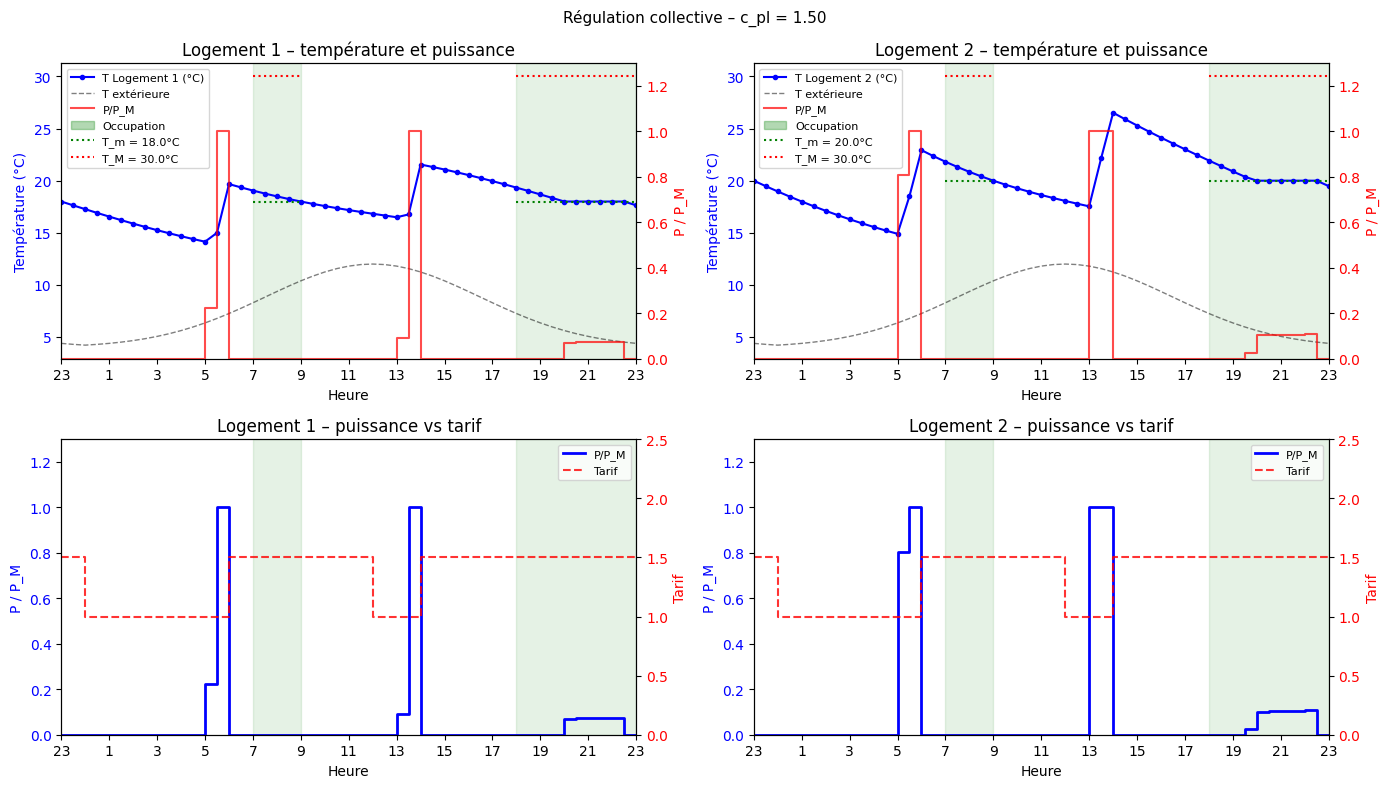

In [24]:
def plot_resultats(P1_sol, P2_sol, T1_sol, T2_sol, c_pl_val):
    c_tarif_loc = np.array([c_cr if heure_creuse(t[i]) else c_pl_val for i in range(N + 1)])
    P1_plot = np.append(P1_sol, 0.0)
    P2_plot = np.append(P2_sol, 0.0)

    # Abscisses monotones pour l'affichage (sans modulo 24)
    t_plot = np.array([t0 + i * dt for i in range(N + 1)])
    t_end  = t0 + N * dt          # = 47.0
    # Ticks : heures "réelles" de 0 à 48, labels ramenés modulo 24
    tick_vals  = list(range(int(t0), int(t_end) + 2, 2))
    tick_lbls  = [str(v % 24) for v in tick_vals]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Régulation collective – c_pl = {c_pl_val:.2f}', fontsize=11)

    for ax in axes.flat:
        # Plages d'occupation exprimées en heures réelles
        for ts, te in [(7, 9), (18, 23), (31, 33), (42, 47)]:
            if ts < t_end and te > t0:
                ax.axvspan(max(ts, t0), min(te, t_end), alpha=0.10, color='green')
        ax.set_xticks(tick_vals)
        ax.set_xticklabels(tick_lbls)
        ax.set_xlim(t0, t_end)
        ax.set_xlabel('Heure')

    occ_patch = mpatches.Patch(color='green', alpha=0.3, label="Occupation")

    for idx, (T_sol, P_plot, T_m, label) in enumerate([
        (T1_sol, P1_plot, T_m1, 'Logement 1'),
        (T2_sol, P2_plot, T_m2, 'Logement 2')
    ]):
        ax = axes[0, idx]
        ax.plot(t_plot, T_sol, 'b-o', markersize=3, label=f'T {label} (°C)')
        ax.plot(t_plot, T_ext, 'k--', linewidth=1, alpha=0.5, label='T extérieure')
        for ts, te in [(7, 9), (18, 23), (31, 33), (42, 47)]:
            if ts < t_end and te > t0:
                ax.hlines(T_m, max(ts, t0), min(te, t_end), colors='green', linestyles=':', linewidth=1.5)
                ax.hlines(T_M, max(ts, t0), min(te, t_end), colors='red',   linestyles=':', linewidth=1.5)
        ax.set_ylabel('Température (°C)', color='b')
        ax.tick_params(axis='y', labelcolor='b')
        ax2 = ax.twinx()
        ax2.step(t_plot, P_plot / P_M, 'r-', where='post', linewidth=1.5, alpha=0.7, label='P/P_M')
        ax2.set_ylabel('P / P_M', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        ax2.set_ylim(0, 1.3)
        lines1, _ = ax.get_legend_handles_labels()
        lines2, _ = ax2.get_legend_handles_labels()
        Tm_line = plt.Line2D([0], [0], color='green', linestyle=':', label=f'T_m = {T_m}°C')
        TM_line = plt.Line2D([0], [0], color='red',   linestyle=':', label=f'T_M = {T_M}°C')
        ax.legend(handles=lines1 + lines2 + [occ_patch, Tm_line, TM_line], fontsize=8, loc='upper left')
        ax.set_title(f'{label} – température et puissance')

        ax = axes[1, idx]
        ax.step(t_plot, P_plot / P_M, 'b-', where='post', linewidth=2, label='P/P_M')
        ax.set_ylabel('P / P_M', color='b')
        ax.tick_params(axis='y', labelcolor='b')
        ax.set_ylim(0, 1.3)
        ax2 = ax.twinx()
        ax2.step(t_plot, c_tarif_loc, 'r--', where='post', linewidth=1.5, alpha=0.8, label='Tarif')
        ax2.set_ylabel('Tarif', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        ax2.set_ylim(0, 2.5)
        lines1, _ = ax.get_legend_handles_labels()
        lines2, _ = ax2.get_legend_handles_labels()
        ax.legend(handles=lines1 + lines2, fontsize=8, loc='upper right')
        ax.set_title(f'{label} – puissance vs tarif')

    plt.tight_layout()
    plt.show()

plot_resultats(P1_opt, P2_opt, T1_opt, T2_opt, c_pl)


**Commentaire.** On retrouve pour les deux logements la stratégie de préchauffage en heures creuses. Le logement 2 ($T^2_m = 20°C$) requiert un préchauffage plus important que le logement 1 ($T^1_m = 18°C$) pour satisfaire sa contrainte de confort plus stricte. Le couplage thermique entre les deux logements joue un rôle : quand le logement 2 chauffe intensément, il transfère de la chaleur vers le logement 1, ce qui permet à ce dernier de réduire légèrement sa propre puissance. L'optimiseur centralisé exploite ce transfert pour minimiser la facture totale.

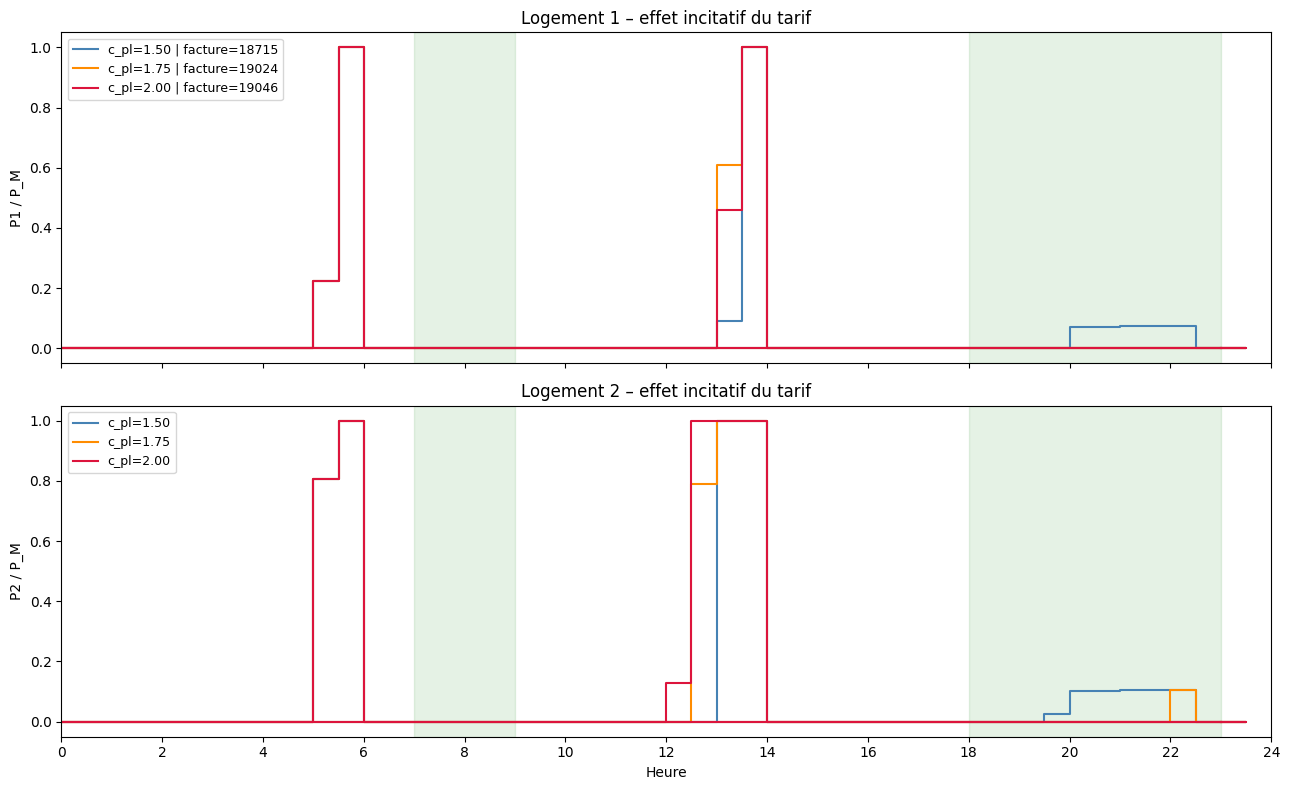

In [25]:
# Effet incitatif du tarif en régulation collective
c_pl_values = [3/2, 7/4, 2]
colors = ['steelblue', 'darkorange', 'crimson']

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for c_pl_v, col in zip(c_pl_values, colors):
    P1_v, P2_v, _, _, facture_v = solve_collectif(c_pl_v)
    axes[0].step(t, np.append(P1_v, 0.0) / P_M, where='post', color=col, linewidth=1.5,
                 label=f'c_pl={c_pl_v:.2f} | facture={facture_v:.0f}')
    axes[1].step(t, np.append(P2_v, 0.0) / P_M, where='post', color=col, linewidth=1.5,
                 label=f'c_pl={c_pl_v:.2f}')

for ax in axes:
    for ts, te in [(7, 9), (18, 23)]:
        ax.axvspan(ts, te, alpha=0.1, color='green')
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlim(0, 24)
    ax.legend(fontsize=9)

axes[0].set_ylabel('P1 / P_M')
axes[1].set_ylabel('P2 / P_M')
axes[1].set_xlabel('Heure')
axes[0].set_title('Logement 1 – effet incitatif du tarif')
axes[1].set_title('Logement 2 – effet incitatif du tarif')

plt.tight_layout()
plt.show()

**Commentaire.** L'effet incitatif est plus marqué pour le logement 1 que pour le logement 2. Le logement 2 est contraint à $T^2_m = 20°C$ : sa contrainte de confort est active quelle que soit la valeur de $c_{pl}$, ce qui bride sa flexibilité. Au sens des conditions KKT (section 2.2.2.1 du cours), le multiplicateur de Lagrange associé à cette contrainte reste strictement positif — la contrainte est active et l'optimiseur ne peut pas s'en écarter. Le logement 1, avec $T^1_m = 18°C$ moins contraignant, dispose d'une plus grande liberté pour reporter sa consommation vers les heures creuses lorsque $c_{pl}$ augmente.